# PJ14 — AI 세부 주제 분석

> **입력**: `output/topic_X_articles.csv` (PJ14_Sungnam_News_Crawling.ipynb 에서 생성)

| 단계 | 내용 |
|---|---|
| 6-0 | 환경 설정 & 분석 대상 CSV 로드 |
| 6-1 | 기사 전문 수집 (n.news.naver.com 재크롤링) |
| 6-2 | AI 분석 에이전트 정의 (pydantic-ai + Gemini) |
| 6-3 | 배치 분석 실행 (체크포인트 자동 저장) |
| 6-4 | 결과 시각화 |
| 6-5 | 분석 결과 CSV 저장 |

In [3]:
from pathlib import Path

# 노트북 디렉터리 탐지 (우선순위 순)
def _find_this_dir() -> Path:
    # 1순위: VSCode Jupyter 전역변수
    nb_file = globals().get("__vsc_ipynb_file__")
    if nb_file:
        return Path(nb_file).parent
    # 2순위: CWD가 프로젝트 루트인 경우 (uv run / jupyter 실행)
    _pj14 = Path.cwd() / "01_Daily_Project" / "PJ14_Sungnam_News_Crawling"
    if _pj14.exists():
        return _pj14
    # 3순위: CWD가 노트북 폴더인 경우
    return Path.cwd()

_THIS_DIR  = _find_this_dir()
OUTPUT_DIR = (_THIS_DIR / "output").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"노트북 폴더: {_THIS_DIR}")
print(f"OUTPUT_DIR : {OUTPUT_DIR}")

노트북 폴더: c:\Users\gorhk\DA_Portfolio\01_Daily_Project\PJ14_Sungnam_News_Crawling
OUTPUT_DIR : C:\Users\gorhk\DA_Portfolio\01_Daily_Project\PJ14_Sungnam_News_Crawling\output


In [4]:
# ─── Step 6-0: 환경 설정 & 분석 대상 CSV 로드 ────────────────────────────────

import os, json, asyncio, time
from dotenv import load_dotenv
import pandas as pd

# .env 로드: 노트북과 같은 폴더 (_THIS_DIR 는 셀 1에서 정의)
_env_path = _THIS_DIR / ".env"
loaded = load_dotenv(_env_path, override=True)
print(f".env 경로: {_env_path}  |  로드: {loaded}")

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "")
GEMINI_MODEL   = os.getenv("GEMINI_MODEL", "gemini-2.0-flash")

assert GEMINI_API_KEY and GEMINI_API_KEY != "your_api_key_here", \
    f"⛔ .env 로드 실패 또는 API KEY 미입력 (경로: {_env_path})"

# ▼ 분석할 토픽 CSV 파일명 지정 ▼
TARGET_CSV = OUTPUT_DIR / "topic_1_articles.csv"

df_ai = pd.read_csv(TARGET_CSV, encoding="utf-8-sig")

print(f"모델   : {GEMINI_MODEL}")
print(f"대상   : {TARGET_CSV.name}")
print(f"기사 수 : {len(df_ai)}건")
df_ai.head(3)

.env 경로: c:\Users\gorhk\DA_Portfolio\01_Daily_Project\PJ14_Sungnam_News_Crawling\.env  |  로드: True
모델   : gemini-3.1-flash-lite-preview
대상   : topic_1_articles.csv
기사 수 : 278건


,keyword,title,press,date,date_str,link,body_preview,crawled_at,매칭_키워드
0,성남시,"김병욱 ""제 기반 잡아준 분당... 은혜 갚기 위해 최선 다하겠다""",오마이뉴스,2024-04-05,2024.04.05.,https://n.news.naver.com/mnews/article/047/000...,"[인터뷰] ""분당 1기 신도시 재건축 문제 해결 할 것... 말꾼 아닌 일꾼 선택해...",2026-04-05 21:50:00,NaN
1,성남시,성남 은행주공 또 시공사 계약해지 추진,파이낸셜뉴스,2024-04-08,2024.04.08.,https://n.news.naver.com/mnews/article/014/000...,"조합측 ""공사비 일방적 증액"" 시공사 ""주변 현장 비교 검토"" 시공사 계약해지를 다...",2026-04-05 21:52:51,NaN
2,성남시,공사비 갈등에…신탁방식 재건축도 '빨간불',한국경제,2024-04-08,2024.04.08.,https://n.news.naver.com/mnews/article/015/000...,"""정비사업 수익성 급속악화 사업 따내도 남는 것 없어"" 입지 좋은 소형 단지에만 관...",2026-04-05 21:52:51,NaN


In [5]:
# ─── Step 6-1: 기사 전문 수집 ────────────────────────────────────────────────
# n.news.naver.com 본문을 재크롤링하여 body_full 컬럼 추가

from curl_cffi import requests as cffi_requests
from bs4 import BeautifulSoup


def fetch_naver_body(url: str, timeout: int = 10) -> str:
    """네이버 뉴스 기사 전문 수집 (최대 3,000자)"""
    try:
        resp = cffi_requests.get(url, impersonate="chrome", timeout=timeout)
        soup = BeautifulSoup(resp.text, "lxml")
        article = soup.select_one("#dic_area") or soup.select_one(".newsct_article")
        return article.get_text(" ", strip=True)[:3000] if article else ""
    except Exception:
        return ""


_BODY_CACHE = OUTPUT_DIR / f"{TARGET_CSV.stem}_body_cache.json"

# 기존 캐시 로드
if _BODY_CACHE.exists():
    with open(_BODY_CACHE, encoding="utf-8") as f:
        body_cache = json.load(f)
    print(f"캐시 로드: {len(body_cache)}건")
else:
    body_cache = {}

# 미수집분만 크롤링
to_crawl = [(i, row) for i, row in df_ai.iterrows() if str(i) not in body_cache]
print(f"신규 수집 대상: {len(to_crawl)}건")

for cnt, (i, row) in enumerate(to_crawl, 1):
    body_cache[str(i)] = fetch_naver_body(row["link"])
    if cnt % 20 == 0:
        with open(_BODY_CACHE, "w", encoding="utf-8") as f:
            json.dump(body_cache, f, ensure_ascii=False)
        print(f"  {cnt}/{len(to_crawl)} 수집 완료")
    time.sleep(0.5)

with open(_BODY_CACHE, "w", encoding="utf-8") as f:
    json.dump(body_cache, f, ensure_ascii=False)

df_ai["body_full"] = [body_cache.get(str(i), "") for i in df_ai.index]
fetched = (df_ai["body_full"].str.len() > 0).sum()
print(f"\n전문 수집 완료: {fetched}/{len(df_ai)}건 성공")

신규 수집 대상: 278건
  20/278 수집 완료
  40/278 수집 완료
  60/278 수집 완료
  80/278 수집 완료
  100/278 수집 완료
  120/278 수집 완료
  140/278 수집 완료
  160/278 수집 완료
  180/278 수집 완료
  200/278 수집 완료
  220/278 수집 완료
  240/278 수집 완료
  260/278 수집 완료

전문 수집 완료: 278/278건 성공


In [6]:
# ─── Step 6-2: pydantic-ai 분석 에이전트 정의 ───────────────────────────────

from pydantic import BaseModel
from pydantic_ai import Agent
from pydantic_ai.models.google import GoogleModel
from typing import List


class ArticleAnalysis(BaseModel):
    세부_주제: str
    관련_이해관계자: List[str]
    문제_유형: str
    한_줄_요약: str


_SYSTEM_PROMPT = """\
당신은 성남시 공공 문제를 분석하는 전문 데이터 분석가입니다.
뉴스 기사를 읽고 아래 항목을 반드시 한국어로 분석해 주세요.

- 세부_주제: 기사의 구체적 주제 (예: "1기 신도시 재건축 사업 지연", "판교 교통 혼잡 개선")
- 관련_이해관계자: 기사에 등장하는 주요 이해관계자 (예: ["성남시청", "LH", "주민협의회"])
- 문제_유형: 아래 중 가장 적합한 하나 선택
  ["예산/재정", "인프라/시설", "주거/부동산", "교통", "환경", "복지/의료", "행정/정책", "안전", "교육", "기타"]
- 한_줄_요약: 기사 핵심 내용 한 문장 (50자 이내)
""".strip()

# GEMINI_API_KEY 환경변수 설정 (GoogleModel이 자동 참조)
os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY

ai_model = GoogleModel(GEMINI_MODEL)
agent = Agent(ai_model, output_type=ArticleAnalysis, system_prompt=_SYSTEM_PROMPT)

print(f"에이전트 초기화 완료 — 모델: {GEMINI_MODEL}")

에이전트 초기화 완료 — 모델: gemini-3.1-flash-lite-preview


In [7]:
# ─── Step 6-3: 배치 분석 실행 ───────────────────────────────────────────────

# ▼ RPM 설정 (Gemini 무료: 15 / 유료: 60~1000) ▼
TARGET_RPM = 15
SLEEP_SEC  = 60 / TARGET_RPM  # 15 RPM → 4.0초

CHECKPOINT_PATH = OUTPUT_DIR / f"{TARGET_CSV.stem}_checkpoint.json"

# 기존 체크포인트 로드
if CHECKPOINT_PATH.exists():
    with open(CHECKPOINT_PATH, encoding="utf-8") as f:
        results = json.load(f)
    print(f"체크포인트 로드: {len(results)}건 기분석")
else:
    results = {}


async def analyze_article(idx: int, row: pd.Series) -> None:
    key = str(idx)
    if key in results:
        return
    text = f"제목: {row['title']}\n\n본문: {row.get('body_full', '') or row.get('body_preview', '')}"
    try:
        result = await agent.run(text)
        results[key] = result.output.model_dump()
    except Exception as e:
        results[key] = {
            "error": str(e),
            "세부_주제": "분석실패",
            "관련_이해관계자": [],
            "문제_유형": "기타",
            "한_줄_요약": "",
        }


async def run_batch() -> None:
    total = len(df_ai)
    for i, (idx, row) in enumerate(df_ai.iterrows()):
        await analyze_article(idx, row)
        if (i + 1) % 20 == 0:
            with open(CHECKPOINT_PATH, "w", encoding="utf-8") as f:
                json.dump(results, f, ensure_ascii=False, indent=2)
            print(f"  {i+1}/{total} 완료 (저장됨)")
        await asyncio.sleep(SLEEP_SEC)
    with open(CHECKPOINT_PATH, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print(f"\n분석 완료: {len(results)}/{total}건")


await run_batch()

# 결과 DataFrame 생성
analysis_list = []
for idx, row in df_ai.iterrows():
    res = results.get(str(idx), {})
    analysis_list.append({
        "title":          row["title"],
        "press":          row["press"],
        "date":           row["date_str"],
        "link":           row["link"],
        "세부_주제":       res.get("세부_주제", ""),
        "관련_이해관계자":  ", ".join(res.get("관련_이해관계자", [])),
        "문제_유형":       res.get("문제_유형", ""),
        "한_줄_요약":      res.get("한_줄_요약", ""),
    })
df_result = pd.DataFrame(analysis_list)
print(df_result["문제_유형"].value_counts())
df_result.head()


  20/278 완료 (저장됨)
  40/278 완료 (저장됨)
  60/278 완료 (저장됨)
  80/278 완료 (저장됨)
  100/278 완료 (저장됨)
  120/278 완료 (저장됨)
  140/278 완료 (저장됨)
  160/278 완료 (저장됨)
  180/278 완료 (저장됨)
  200/278 완료 (저장됨)
  220/278 완료 (저장됨)
  240/278 완료 (저장됨)
  260/278 완료 (저장됨)

분석 완료: 278/278건
문제_유형
주거/부동산    205
교통         33
행정/정책      15
예산/재정       8
인프라/시설      7
복지/의료       5
안전          2
환경          2
기타          1
Name: count, dtype: int64


,title,press,date,link,세부_주제,관련_이해관계자,문제_유형,한_줄_요약
0,"김병욱 ""제 기반 잡아준 분당... 은혜 갚기 위해 최선 다하겠다""",오마이뉴스,2024.04.05.,https://n.news.naver.com/mnews/article/047/000...,분당 1기 신도시 재건축 사업 추진 및 지역 현안 해결,"김병욱 후보(더불어민주당), 분당 주민, 성남시청",주거/부동산,김병욱 후보가 분당 1기 신도시 재건축 신속 추진 및 지역 경제 활성화를 공약하며 ...
1,성남 은행주공 또 시공사 계약해지 추진,파이낸셜뉴스,2024.04.08.,https://n.news.naver.com/mnews/article/014/000...,은행주공 재건축 공사비 갈등에 따른 시공사 계약해지 추진,"은행주공 재건축 조합, GS건설·HDC현대산업개발 컨소시엄",주거/부동산,성남 은행주공 재건축 조합이 공사비 증액 갈등으로 시공사 계약해지를 다시 추진한다.
2,공사비 갈등에…신탁방식 재건축도 '빨간불',한국경제,2024.04.08.,https://n.news.naver.com/mnews/article/015/000...,공사비 상승에 따른 신탁방식 재건축 사업 차질,"부동산신탁사, 재건축 조합 및 주민, 성남시청",주거/부동산,공사비 상승과 업황 악화로 신탁사들이 선별 수주에 나서며 신탁방식 재건축 사업이 지...
3,[격전지 투표장] ‘분당을’ 정자교·재건축 문제 누가 해결할까?,국민일보,2024.04.10.,https://n.news.naver.com/mnews/article/005/000...,분당구 정자교 보수 지연 및 1기 신도시 재건축 문제,"성남시 분당구 유권자, 더불어민주당 김병욱 후보, 국민의힘 김은혜 후보, 성남시청",주거/부동산,분당구 총선 후보들은 정자교 보수 지연 해결과 1기 신도시 재건축 추진을 핵심 지역...
4,"성남 은행주공, GS건설·HDC현산과 재건축 시공계약 해지",디지털타임스,2024.04.15.,https://n.news.naver.com/mnews/article/029/000...,성남 은행주공 재건축 공사비 갈등에 따른 시공 계약 해지,"성남 은행주공 재건축조합, GS건설, HDC현대산업개발",주거/부동산,성남 은행주공 재건축조합이 공사비 인상 갈등으로 GS건설·HDC현대산업개발 컨소시엄...


In [8]:
df_result['문제_유형'].value_counts()

문제_유형
주거/부동산    205
교통         33
행정/정책      15
예산/재정       8
인프라/시설      7
복지/의료       5
안전          2
환경          2
기타          1
Name: count, dtype: int64

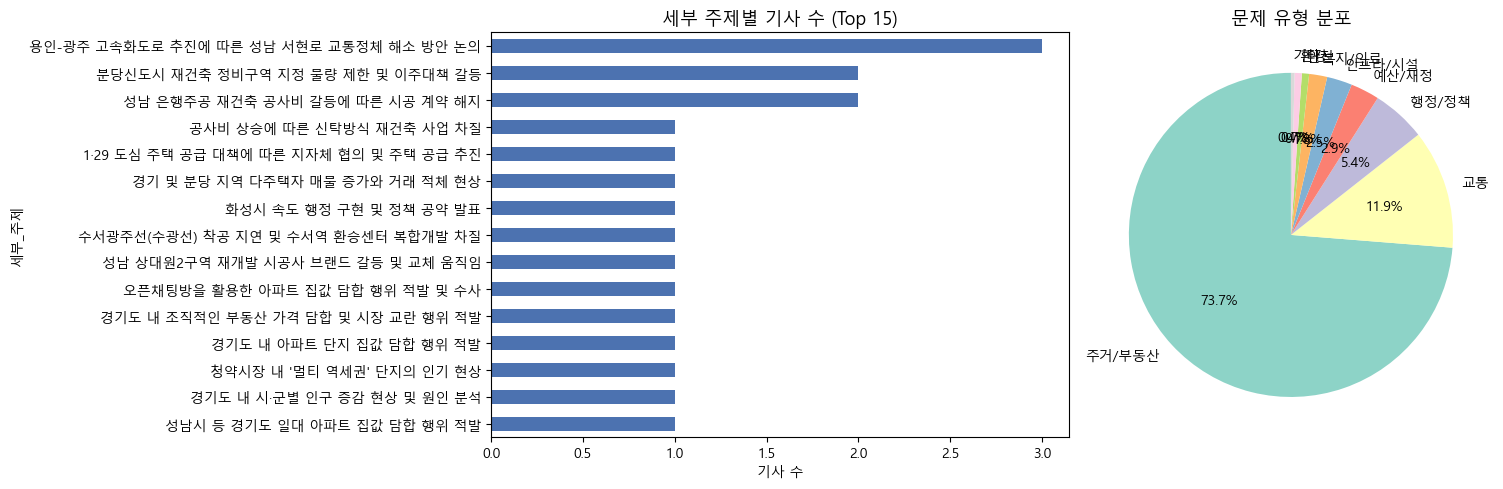

시각화 저장 완료


In [9]:
# ─── Step 6-4: 결과 시각화 ──────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ① 세부_주제별 기사 수 (상위 15)
topic_counts = df_result["세부_주제"].value_counts().head(15)
topic_counts.plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("세부 주제별 기사 수 (Top 15)", fontsize=13)
axes[0].set_xlabel("기사 수")
axes[0].invert_yaxis()

# ② 문제_유형 분포
type_counts = df_result["문제_유형"].value_counts()
type_counts.plot(
    kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90,
    colors=plt.cm.Set3.colors[:len(type_counts)],
)
axes[1].set_title("문제 유형 분포", fontsize=13)
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / f"{TARGET_CSV.stem}_ai분석_시각화.png",
    dpi=150, bbox_inches="tight",
)
plt.show()
print("시각화 저장 완료")

In [10]:
# ─── Step 6-5: 분석 결과 CSV 저장 ──────────────────────────────────────────

save_path = OUTPUT_DIR / f"{TARGET_CSV.stem}_ai_분석결과.csv"
df_result.to_csv(save_path, index=False, encoding="utf-8-sig")
print(f"저장 완료: {save_path.name}")
print(f"컬럼: {list(df_result.columns)}")
df_result.head()

저장 완료: topic_1_articles_ai_분석결과.csv
컬럼: ['title', 'press', 'date', 'link', '세부_주제', '관련_이해관계자', '문제_유형', '한_줄_요약']


,title,press,date,link,세부_주제,관련_이해관계자,문제_유형,한_줄_요약
0,"김병욱 ""제 기반 잡아준 분당... 은혜 갚기 위해 최선 다하겠다""",오마이뉴스,2024.04.05.,https://n.news.naver.com/mnews/article/047/000...,분당 1기 신도시 재건축 사업 추진 및 지역 현안 해결,"김병욱 후보(더불어민주당), 분당 주민, 성남시청",주거/부동산,김병욱 후보가 분당 1기 신도시 재건축 신속 추진 및 지역 경제 활성화를 공약하며 ...
1,성남 은행주공 또 시공사 계약해지 추진,파이낸셜뉴스,2024.04.08.,https://n.news.naver.com/mnews/article/014/000...,은행주공 재건축 공사비 갈등에 따른 시공사 계약해지 추진,"은행주공 재건축 조합, GS건설·HDC현대산업개발 컨소시엄",주거/부동산,성남 은행주공 재건축 조합이 공사비 증액 갈등으로 시공사 계약해지를 다시 추진한다.
2,공사비 갈등에…신탁방식 재건축도 '빨간불',한국경제,2024.04.08.,https://n.news.naver.com/mnews/article/015/000...,공사비 상승에 따른 신탁방식 재건축 사업 차질,"부동산신탁사, 재건축 조합 및 주민, 성남시청",주거/부동산,공사비 상승과 업황 악화로 신탁사들이 선별 수주에 나서며 신탁방식 재건축 사업이 지...
3,[격전지 투표장] ‘분당을’ 정자교·재건축 문제 누가 해결할까?,국민일보,2024.04.10.,https://n.news.naver.com/mnews/article/005/000...,분당구 정자교 보수 지연 및 1기 신도시 재건축 문제,"성남시 분당구 유권자, 더불어민주당 김병욱 후보, 국민의힘 김은혜 후보, 성남시청",주거/부동산,분당구 총선 후보들은 정자교 보수 지연 해결과 1기 신도시 재건축 추진을 핵심 지역...
4,"성남 은행주공, GS건설·HDC현산과 재건축 시공계약 해지",디지털타임스,2024.04.15.,https://n.news.naver.com/mnews/article/029/000...,성남 은행주공 재건축 공사비 갈등에 따른 시공 계약 해지,"성남 은행주공 재건축조합, GS건설, HDC현대산업개발",주거/부동산,성남 은행주공 재건축조합이 공사비 인상 갈등으로 GS건설·HDC현대산업개발 컨소시엄...
